# Multi-Robot Stick-Carrying via Value Iteration

Two robots rigidly hold the ends of a stick and must cooperatively carry it
across a stochastic grid world to a goal cell. We model the task as a Markov
Decision Process and solve it with **value iteration**.

Reference: Hu & Wellman, *Nash Q-Learning for General-Sum Stochastic Games*,
JMLR 2003 — https://jmlr.csail.mit.edu/papers/volume4/hu03a/hu03a.pdf

> All logic lives in the [`stick_carrying/`](stick_carrying/) package
> (object-oriented, built on an abstract `MDP` base class). This notebook is a
> thin **visualisation demo** that just imports and drives that package.

In [1]:
%matplotlib inline
import numpy as np
from stick_carrying import (StickCarryingMDP, StickState, Orientation,
                            ValueIterationSolver, Simulator, StickVisualizer)

rng = np.random.default_rng(7)
start = StickState(0, 0, Orientation.HORIZONTAL)
mdp = StickCarryingMDP.random_solvable(size=10, start=start, goal_cell=(9, 9),
                                       rng=rng, p_main=0.8, discount=0.95)
viz = StickVisualizer(mdp)
print(f"{len(mdp.states())} valid stick configurations | "
      f"grid found on attempt {mdp.generation_attempts}")

140 valid stick configurations | grid found on attempt 0


## 1. The stochastic environment

`1` = free, `0` = obstacle. The stick (brown) is held by robot **A** (blue) and
robot **B** (red); the gold star is the goal. With probability `p_main = 0.8` an
action succeeds, otherwise the robots *slip* and translate in a random
direction.

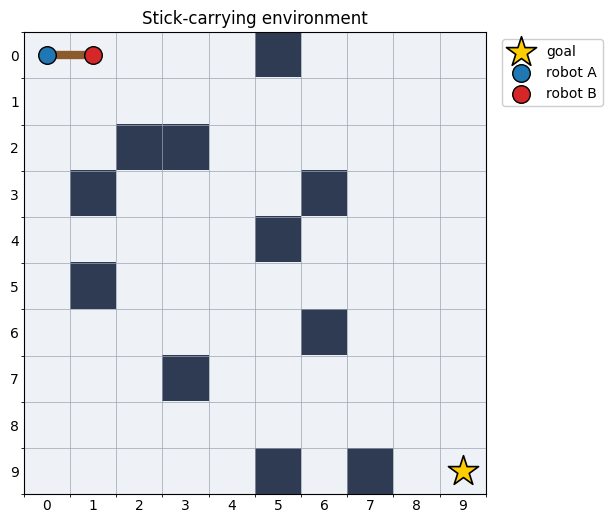

In [2]:
viz.plot_environment();

## 2. Planning with value iteration

We sweep the Bellman optimality backup
$V(s)\leftarrow\max_a\sum_{s'}P(s'\mid s,a)\,[R+\gamma V(s')]$ until it
converges.

converged in 44 sweeps | V*(start) = 23.46


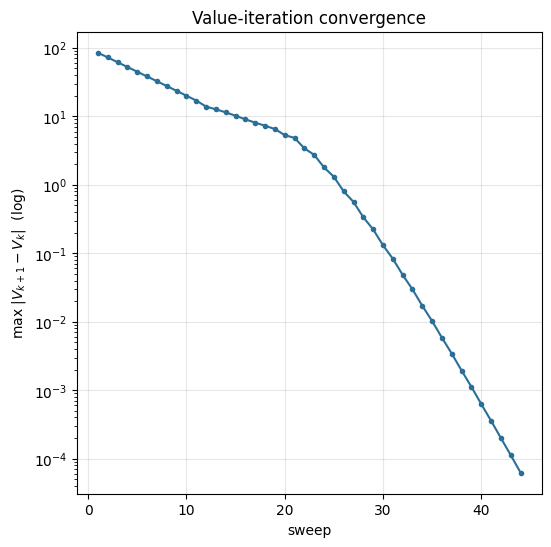

In [3]:
solver = ValueIterationSolver(mdp, theta=1e-4)
policy = solver.solve()
print(f"converged in {len(solver.history)} sweeps | "
      f"V*(start) = {policy.value(start):.2f}")
viz.plot_convergence(solver.history);

## 3. Optimal value function and policy

The value of each cell is the best value over the two stick orientations anchored
there. The white line is the path the robots *intend* to follow; arrows show the
greedy translation, magenta circles mark cells where rotating is optimal.

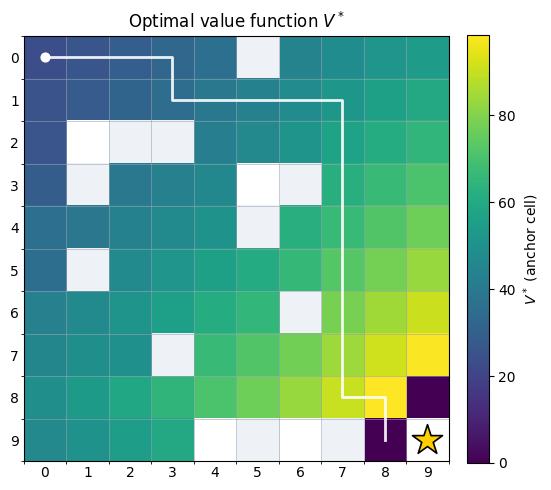

In [4]:
sim = Simulator(mdp, policy)
viz.plot_value_function(policy, intended_path=sim.intended_path(start));

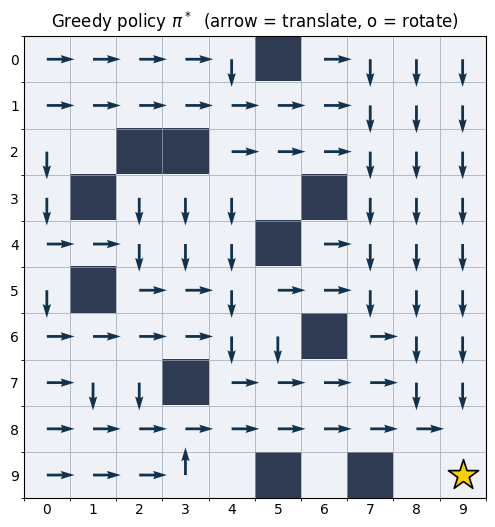

In [5]:
viz.plot_policy(policy);

## 4. Stochastic roll-out of the optimal policy

We execute the policy in the stochastic environment. Slips make the realised
path wander, but the policy keeps steering the stick back toward the goal.

reached goal in 19 steps (success=True)


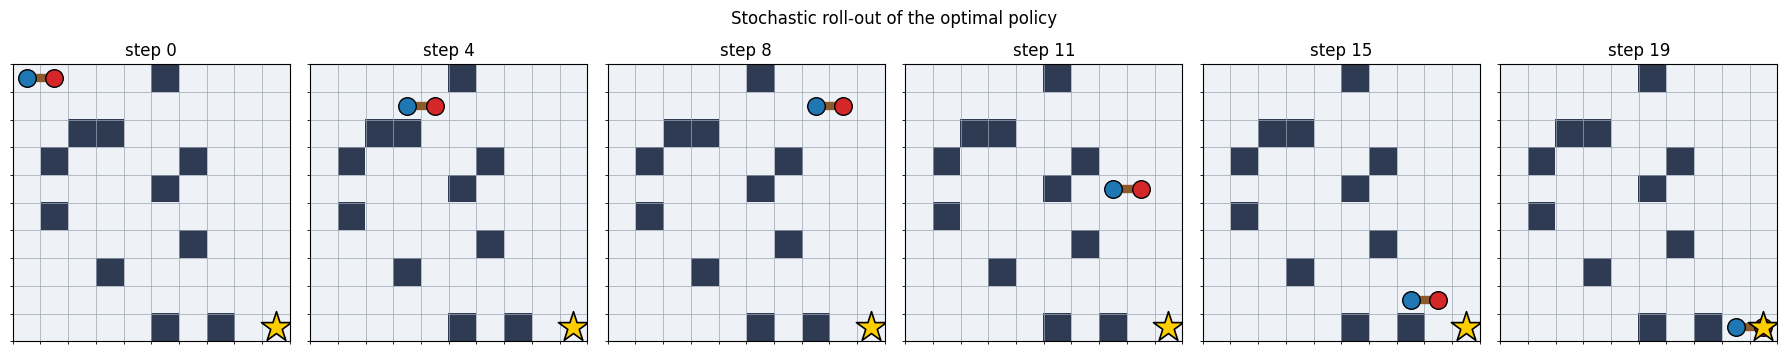

In [6]:
trajectory = sim.run(start, rng=np.random.default_rng(3))
print(f"reached goal in {len(trajectory) - 1} steps "
      f"(success={mdp.is_terminal(trajectory[-1])})")
viz.plot_trajectory_snapshots(trajectory, k=6);

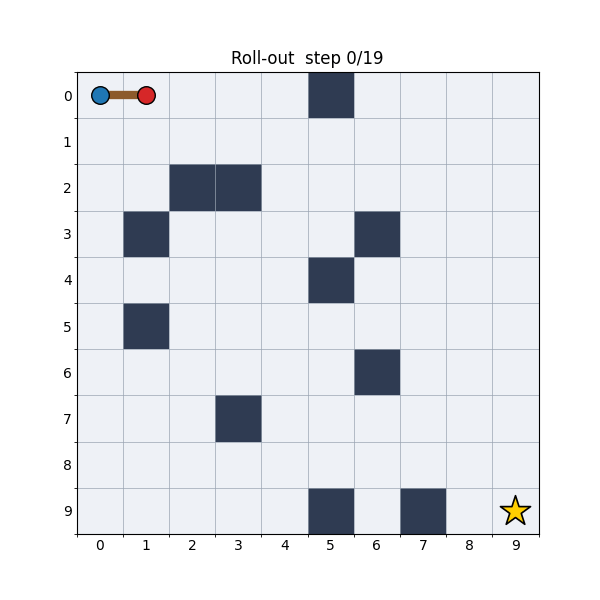

In [7]:
from IPython.display import Image
viz.animate(trajectory, filename="outputs/rollout.gif", fps=3)
Image(filename="outputs/rollout.gif")